In [206]:
%pip install matplot2tikz matplotlib "webcolors<24.6.0"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\SerKin0\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
%pip install tikzplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\SerKin0\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# --------------------------- Подключение библиотек -------------------------- #
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches

ImportError: cannot import name 'common_texification' from 'matplotlib.backends.backend_pgf' (C:\Users\SerKin0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\matplotlib\backends\backend_pgf.py)

In [3]:
# --------------------------------- Константы -------------------------------- #
# Угол преломления и погрешность (получен по измерениям транспортира) (Градус)
beta = 22
delta_beta = 0.5

# Показатель преломления среды
n = 1

# Длина волны света
lam = 0.589 * 1e-6

# Абсолютная погрешность диаметра колец Ньютона
delta_d = 5 * 1e-6

In [4]:
# --------------------------- Результаты измерений --------------------------- #
test_1 = {10: 31.81, 9: 31.93, 8: 31.55, 7: 31.72, 6: 32.39, 5: 32.03, 4: 32.22, 3: 32.46, 2: 32.74, 1: 33.06, -1: 34.06, -2: 35.0, -3: 35.31, -4: 35.53, -5: 35.71, -6: 35.88, -7: 36.05, -8: 36.2, -9: 36.36, -10: 36.48}
test_2 = {10: 31.2, 9: 31.43, 8: 31.59, 7: 31.71, 6: 31.86, 5: 32.02, 4: 32.22, 3: 32.45, 2: 32.73, 1: 33.09, -1: 34.62, -2: 34.99, -3: 35.26, -4: 35.5, -5: 35.69, -6: 35.87, -7: 36.03, -8: 36.18, -9: 36.34, -10: 36.48}
test_3 = {10: 31.2, 9: 31.43, 8: 31.57, 7: 31.72, 6: 31.9, 5: 32.04, 4: 32.26, 3: 32.47, 2: 32.74, 1: 33.08, -1: 34.63, -2: 35.02, -3: 35.29, -4: 35.56, -5: 35.75, -6: 35.91, -7: 36.06, -8: 36.19, -9: 36.36, -10: 36.49}
test_4 = {10: 31.28, 9: 31.43, 8: 31.58, 7: 31.71, 6: 31.89, 5: 32.02, 4: 32.21, 3: 32.74, 2: 32.77, 1: 33.07, -1: 34.61, -2: 35.02, -3: 35.27, -4: 35.5, -5: 35.69, -6: 35.89, -7: 36.04, -8: 36.17, -9: 36.33, -10: 36.49}

In [5]:
def d_k(array: dict) -> dict:
    """Определение диаметра кольца Ньютона"""
    if len(array) % 2 != 0:
        raise ValueError(f"Количество колец не равно: {len(array)} % 2 != 0")
    return {i+1: abs(array[i+1] - array[-i-1]) for i in range(len(array) // 2)}

In [6]:
mat = []
for test in (test_1, test_2, test_3, test_4):
    mat.append(list(d_k(test).values()))
print(mat)

[[1.0, 2.259999999999998, 2.8500000000000014, 3.3100000000000023, 3.6799999999999997, 3.490000000000002, 4.329999999999998, 4.650000000000002, 4.43, 4.669999999999998], [1.529999999999994, 2.260000000000005, 2.809999999999995, 3.280000000000001, 3.6699999999999946, 4.009999999999998, 4.32, 4.59, 4.910000000000004, 5.279999999999998], [1.5500000000000043, 2.280000000000001, 2.8200000000000003, 3.3000000000000043, 3.710000000000001, 4.009999999999998, 4.340000000000003, 4.619999999999997, 4.93, 5.290000000000003], [1.5399999999999991, 2.25, 2.530000000000001, 3.289999999999999, 3.6699999999999946, 4.0, 4.329999999999998, 4.590000000000003, 4.899999999999999, 5.210000000000001]]


In [7]:
def R(beta: int, n: int, lam: float, d_k: float, k: int) -> float:
    """Нахождение радиуса линзы"""
    result = (n * math.cos(math.radians(beta))) / (4 * lam) * (d_k**2) / (k)
    return result

def delta_R(beta: int, n: int, lam: float, d_k: float, k: int, delta_beta: float, delta_d: float) -> float:
    first = n / (4 * lam * k)
    second = 2 * d_k * delta_d * math.cos(math.radians(beta))
    three = d_k**2 * delta_beta * math.sin(math.radians(beta))
    return first * (second + three)

In [8]:
r_list = []

for test in (test_2, test_3, test_4):
    temp = []
    for k in range(1, 11):
        d = d_k(test).get(k) * 1e-3
        temp.append(round(R(beta, n, lam, d, k) * 1000, 3))
    r_list.append(temp)

for row in r_list:
    print('\t'.join(map(str, row)).replace('.', ','))

921,241	1005,026	1035,814	1058,469	1060,114	1054,698	1049,204	1036,397	1054,171	1097,131
945,484	1022,893	1043,2	1071,417	1083,349	1054,698	1058,942	1049,988	1062,776	1101,291
933,323	996,152	839,673	1064,933	1060,114	1049,444	1054,067	1036,397	1049,881	1068,233


In [9]:
delta_r_list = []

for test in (test_2, test_3, test_4):
    temp = []
    for k in range(1, 11):
        d = d_k(test).get(k) * 1e-3
        temp.append(round(delta_R(beta, n, lam, d, k, delta_beta, delta_d) * 1000, 3))
    delta_r_list.append(temp)

for row in delta_r_list:
    print('\t'.join(map(str, row)).replace('.', ','))

192,124	207,476	212,934	217,052	217,046	215,693	214,382	211,624	215,103	223,713
197,1	211,124	214,439	219,687	221,771	215,693	216,36	214,384	216,851	224,557
194,604	205,663	172,944	218,367	217,046	214,625	215,37	211,624	214,232	217,847


In [10]:
def draw_rectangle_error(x_points: float | list, y_points: float | list, errors_x: float | list, errors_y: float | list) -> list:
    rectangles = []
    
    if not isinstance(x_points, (list, tuple)):
        x_points = [x_points]
    
    if not isinstance(y_points, (list, tuple)):
        y_points = [y_points]
    
    if not isinstance(errors_x, (list, tuple)):
        errors_x = [errors_x]
    
    if not isinstance(errors_y, (list, tuple)):
        errors_y = [errors_y]
    
    
    for x, y, err_x, err_y in zip(x_points, y_points, errors_x, errors_y):
        rectangles.append(patches.Rectangle(
            (x - err_x, y - err_y),
            2 * err_x,
            2 * err_y,
            linewidth=1,
            edgecolor='red',
            facecolor='red',
            alpha=0.3
        ))
    return rectangles

In [11]:
import webcolors
print(webcolors.__version__)

1.13


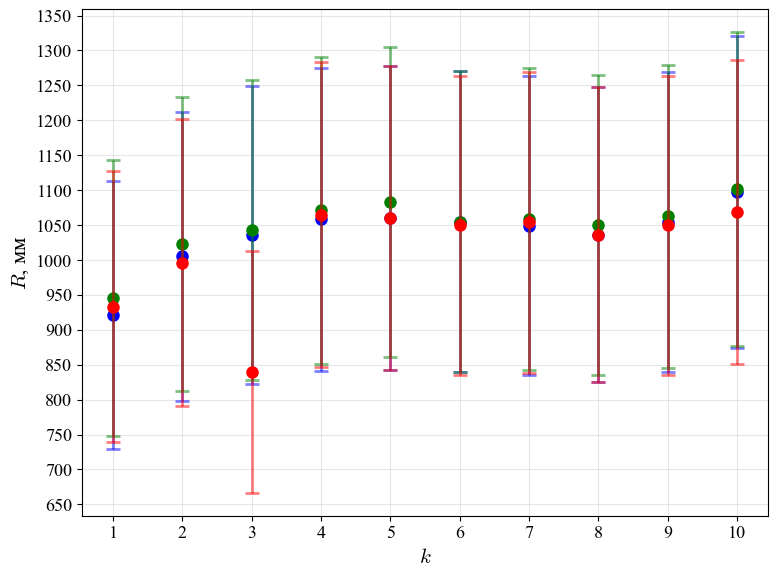

In [19]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['text.usetex'] = False

fig, ax = plt.subplots(figsize=(8, 6))  # + явный размер

y_points = [i for i in range(1, 11)]

colors = [
    'blue', 
    'green',
    'red', 
]

for index, (r, de_r, col) in enumerate(zip(r_list, delta_r_list, colors)):
    ax.plot(y_points, r, 'o', markersize=8, color=col, label=f"Измерение {index+1}")
    ax.errorbar(y_points, r,
                yerr=de_r,
                fmt='none',
                capsize=5,
                capthick=2,
                elinewidth=2,
                ecolor=col,
                alpha=0.5)
plt.xlabel("$k$")
plt.ylabel("$R$, мм")
plt.xticks(y_points)
plt.yticks([i for i in range(650, 1400, 50)])
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('graph1.pdf', bbox_inches='tight')
plt.show()